Please upload 'car_data.csv':


Saving car_data.csv to car_data (4).csv


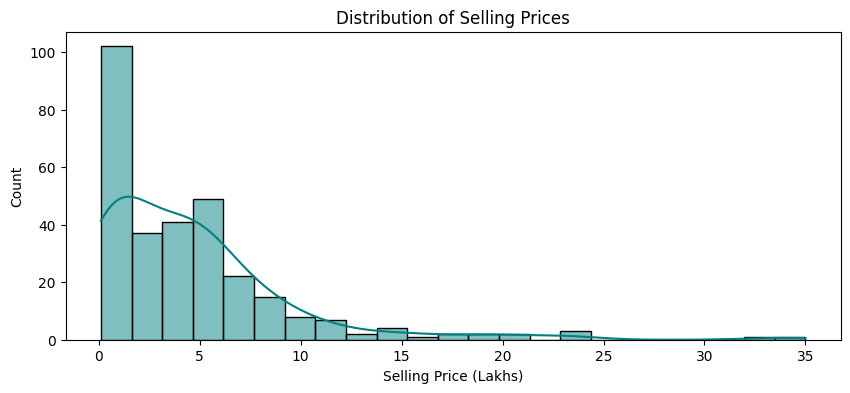

/tmp/ipykernel_6781/2416830568.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')


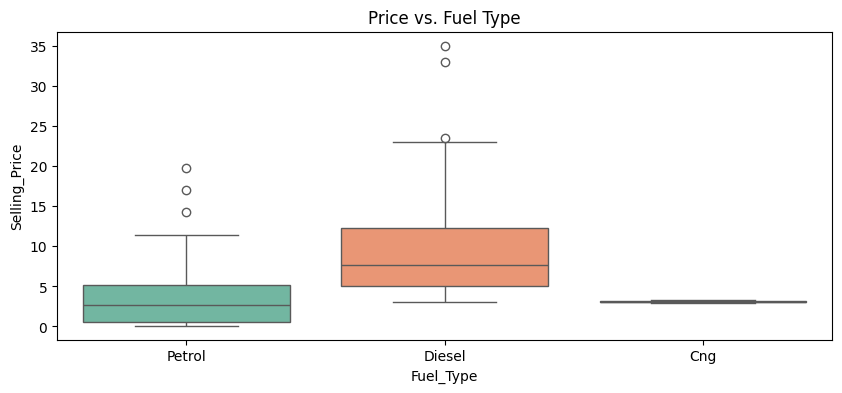

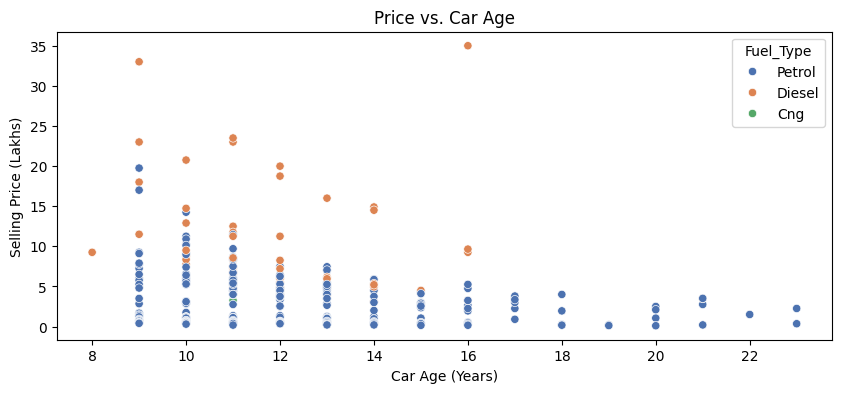

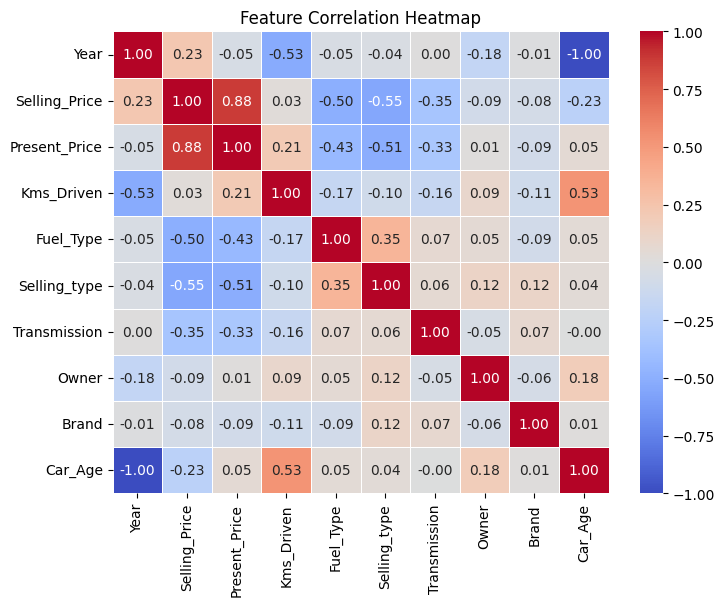

--- Linear Regression Evaluation ---
MAE: 1.54
RMSE: 2.58
R² Score: 0.74

--- Random Forest Regressor Evaluation ---
MAE: 1.29
RMSE: 3.12
R² Score: 0.62


/tmp/ipykernel_6781/2416830568.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


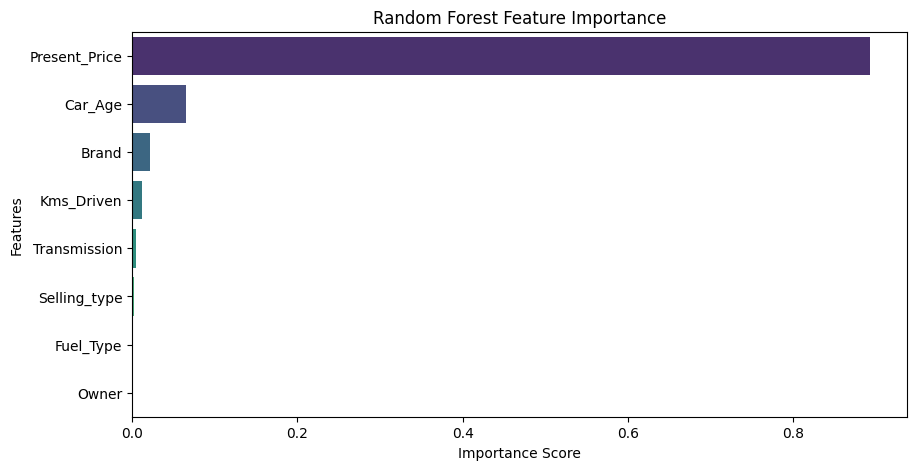

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 1: Upload dataset
print("Please upload 'car_data.csv':")
uploaded = files.upload()
car_file = [f for f in uploaded.keys() if 'car' in f.lower()][0]
df = pd.read_csv(car_file)

# Step 2: Data Cleaning (handling nulls, duplicates, and inconsistent categories)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

if 'Seller_Type' in df.columns:
    df.rename(columns={'Seller_Type': 'Selling_type'}, inplace=True)

for col in ['Fuel_Type', 'Selling_type', 'Transmission']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.capitalize()

# Step 3: Feature Engineering (Car Age & Brand Extraction)
df['Brand'] = df['Car_Name'].apply(lambda x: str(x).split()[0].capitalize())
df['Car_Age'] = 2026 - df['Year']
df.drop(columns=['Car_Name'], inplace=True)

# Step 4: Exploratory Data Analysis (EDA) & Visualizations
plt.figure(figsize=(10, 4))
sns.histplot(df['Selling_Price'], kde=True, color='teal')
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price (Lakhs)')
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')
plt.title('Price vs. Fuel Type')
plt.show()

plt.figure(figsize=(10, 4))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df, hue='Fuel_Type', palette='deep')
plt.title('Price vs. Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (Lakhs)')
plt.show()

# Step 5: Encode Categorical Variables
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Step 6: Feature Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Step 7: Train/Test Split
X = df.drop(columns=['Selling_Price', 'Year'])
y = df['Selling_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8: Train Multiple Regression Models
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Model 2: Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Step 9: Model Evaluation (MAE, RMSE, R² Score)
print("--- Linear Regression Evaluation ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_lr):.2f}")

print("\n--- Random Forest Regressor Evaluation ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_rf):.2f}")

# Step 10: Feature Importance Chart for Best Model (Random Forest)
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()